# Προ-Επεξεργασία των Εικόνων

## Φόρτωση των δεδομένων

In [2]:
import tensorflow as tf
import csv
import numpy as np
from pathlib import Path
import kagglehub
from PIL import Image
import matplotlib.pyplot as plt
from kagglehub import KaggleDatasetAdapter

path = Path(kagglehub.dataset_download("marquis03/fruits-100"))
filename_names = path / "classname.txt"
filename_train = path / "train.csv"
filename_test = path / "test.csv"
filename_vali = path / "val.csv"


# load data
def take_fruit_names(filename):
    fruit_names = {}
    fruit_id  = 0
    with open(filename, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split(',')
            fruit_name = parts[0]
            fruit_names[fruit_id] = fruit_name
            fruit_id += 1            
    return fruit_names


def load_data_fruit_paths(path):
   image_paths = []
   with open(path, 'r', newline='') as csvfile:
        reader = csv.reader(csvfile)
        next(reader)
        for row in reader:
            image_paths.append(row[0])
   return image_paths

def load_data_fruit_category(path):
   image_category = []
   with open(path, 'r', newline='') as csvfile:
        reader = csv.reader(csvfile)
        next(reader)
        for row in reader:
            image_category.append(row[1])
   return image_category

fruit_names = take_fruit_names(filename_names)
train_image_paths = load_data_fruit_paths(filename_train)
train_image_category = load_data_fruit_category(filename_train)

test_image_paths = load_data_fruit_paths(filename_test)

vali_image_paths = load_data_fruit_paths(filename_vali)
vali_image_category = load_data_fruit_category(filename_vali)
print("OK")


OK


## Αλλαγή Μεγέθους και Κανονικοποίηση των Εικόνων

In [5]:
import tensorflow as tf

IMG_SIZE = (224,224)
BATCH_SIZE = 16

def load_image(path, label=None):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32) / 255.0
    if label is None:
        return image
    return image, label

# Train dataset
train_paths = [str(path / p) for p in train_image_paths]
train_labels = tf.convert_to_tensor([int(x) for x in train_image_category], dtype=tf.int32)

train_ds = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_ds = train_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(5000)
train_ds = train_ds.batch(BATCH_SIZE)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

# Validation dataset
vali_paths = [str(path / p) for p in vali_image_paths]
vali_labels = tf.convert_to_tensor([int(x) for x in vali_image_category], dtype=tf.int32)

val_ds = tf.data.Dataset.from_tensor_slices((vali_paths, vali_labels))
val_ds = val_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

# Test dataset
test_paths = [str(path / p) for p in test_image_paths]

test_ds = tf.data.Dataset.from_tensor_slices(test_paths)
test_ds = test_ds.map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

## Μοντέλο και Τρέξιμο

Epoch 1/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 90s 33ms/step - accuracy: 0.0700 - loss: 3.7062 - val_accuracy: 0.0196 - val_loss: 5.5787
Epoch 2/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 86s 33ms/step - accuracy: 0.1373 - loss: 3.1513 - val_accuracy: 0.0282 - val_loss: 6.1630
Epoch 3/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 86s 33ms/step - accuracy: 0.1917 - loss: 2.9190 - val_accuracy: 0.0384 - val_loss: 5.8236
Epoch 4/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 87s 33ms/step - accuracy: 0.2407 - loss: 2.7138 - val_accuracy: 0.0510 - val_loss: 5.7496
Epoch 5/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 85s 33ms/step - accuracy: 0.2709 - loss: 2.5712 - val_accuracy: 0.0584 - val_loss: 5.4205
Epoch 6/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 85s 33ms/step - accuracy: 0.2971 - loss: 2.4548 - val_accuracy: 0.0584 - val_loss: 5.8720
Epoch 7/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 86s 33ms/step - accuracy: 0.3146 - loss: 2.3905 - val_accuracy: 0.0630 - val_loss: 5.6087
Epoch 8/50
2500/2500 ━━━━━━━━━━━━━━━━━━━━ 86s 33ms/step - accuracy: 0.3421 -

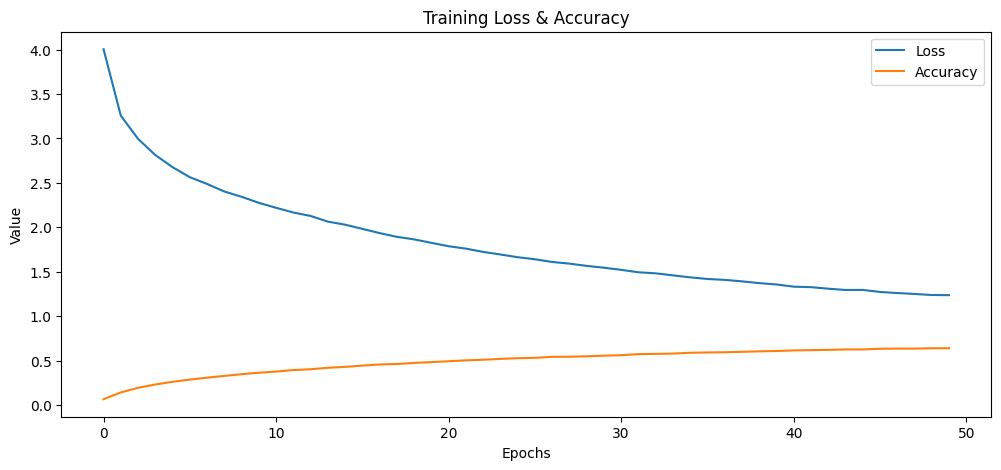

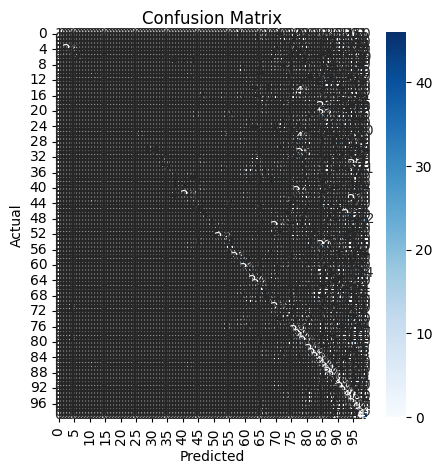

In [7]:
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import (
    Dense,
    InputLayer,
    BatchNormalization,
    Conv2D,
    MaxPooling1D,
    Flatten,
    Dropout
)
from tensorflow.keras.applications.efficientnet import preprocess_input
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
import numpy as np
from tensorflow import keras
from tensorflow.keras import Input, layers, models
from tensorflow.keras.applications import EfficientNetB0
from sklearn.metrics import (
    confusion_matrix, 
    f1_score, 
    precision_score, 
    recall_score,
    accuracy_score
)

# Παράμετροι εκπαίδευσης
BATCH_SIZE = 20
EPOCHS = 50

def generator_data(images, labels, BATCH_SIZE):
    num_samples = len(images)
    while True:
        for offset in range(0, num_samples, BATCH_SIZE):
            batch_images = images[offset:offset+BATCH_SIZE]
            batch_labels = labels[offset:offset+BATCH_SIZE]
            yield batch_images, batch_labels
    

def build_model(num_classes, input_shape):
    
    data_augmentation = keras.Sequential([
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
        layers.RandomContrast(0.1),
    ])

    inputs = Input(shape=input_shape)

    x = data_augmentation(inputs)

    # CNN Block 1
    x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2,2))(x)

    # CNN Block 2
    x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2,2))(x)

    # CNN Block 3
    x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2,2))(x)

    # CNN Block 4
    x = layers.Conv2D(256, (3,3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2,2))(x)

    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dropout(0.4)(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.3)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inputs, outputs)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

def Processing_data(image_fruit_train_image_labels, image_fruit_vali_image_labels):

    encoder = LabelEncoder()

    image_fruit_train_image_labels_enc = encoder.fit_transform(image_fruit_train_image_labels)
    image_fruit_vali_image_labels_enc  = encoder.transform(image_fruit_vali_image_labels)

    num_classes = len(np.unique(image_fruit_train_image_labels_enc))

    return image_fruit_train_image_labels_enc, image_fruit_vali_image_labels_enc, num_classes, encoder

def run_model(train_ds, val_ds, num_classes, input_shape=(224,224,3), epochs=20):
    tf.keras.backend.clear_session()

    # Δημιουργία του μοντέλου
    model = build_model(num_classes, input_shape)

    # Εκπαίδευση μοντέλου (μία φάση)
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=epochs
    )

    # Predictions και μετρικές
    y_true = []
    y_pred = []

    for images, labels in val_ds:
        preds = model.predict(images, verbose=0)

        y_true.extend(labels.numpy())          # labels είναι ήδη class ids
        y_pred.extend(np.argmax(preds, axis=1))

    cf = confusion_matrix(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)
    accuracy = accuracy_score(y_true, y_pred)

    return history, cf, f1, precision, recall, accuracy, model

def main():

    num_classes = len(set(train_image_category))

    history, cf, f1, precision, recall, accuracy, model = run_model(
        train_ds,
        val_ds,
        num_classes,
        epochs=EPOCHS
    )

    print(f"Precision: {precision:.4}")
    print(f"Recall: {recall:.4}")
    print(f"F1 score: {f1:.4}")
    print(f"Accuracy: {accuracy:.4}");print(f"Accuracy: {accuracy:.4}")

    # Γράφημα training
    import matplotlib.pyplot as plt

    plt.figure(figsize=(12,5))
    plt.plot(history.history['loss'], label='Loss')
    plt.plot(history.history['accuracy'], label='Accuracy')
    plt.xlabel("Epochs")
    plt.ylabel("Value")
    plt.legend()
    plt.title("Training Loss & Accuracy")
    plt.show()

    # Confusion matrix
    import seaborn as sns
    plt.figure(figsize=(5,5))
    sns.heatmap(cf, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()
    
if __name__ == "__main__":
    main()